In [4]:
# 感知机中的if res>0 return 1 ... 这几行语句可以视作一个函数h(x)，而且是一个阶跃函数。阶跃函数也是一个非线性函数
# 所以感知机的输出可以写成 f(x) = w1x1+w2x2 -> output = h(f(x)) 其中，h(x)是阶跃函数
import numpy as np
import matplotlib.pylab as plt
def step_functions(x: np.array) -> np.array:
    # 接受一个ndarray，并且准换为布尔型数组
    # [-2,0,1] -> [false,true,true]
    y = x > 0
    # 再转换为数字[false,true,true] -> [0,1,1]
    return y.astype(int)

print(f"阶跃函数的输出测试：输入[-3,-2,0,1,2],结果为{step_functions(np.array([-3,-2,0,1,2]))}")

阶跃函数的输出测试：输入[-3,-2,0,1,2],结果为[0 0 0 1 1]


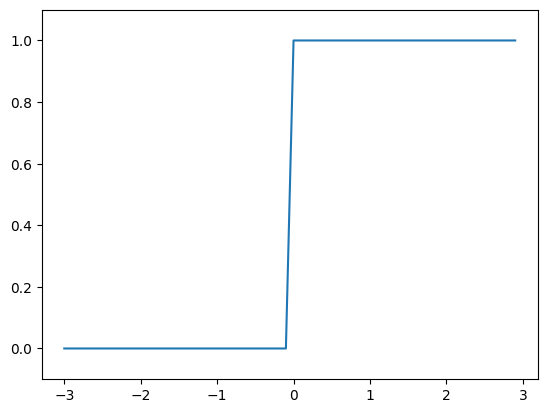

In [5]:
# 生成指定步长，指定范围内数据
x = np.arange(-3, 3, 0.1)
y = step_functions(x)

plt.plot(x,y)
# y轴范围
plt.ylim(-0.1,1.1)
plt.show()

In [6]:
# 既然阶跃函数h(x)是一种映射，负责当超过某个阈值时输出，那么就可以更换其他函数->激活函数
# 实现最基本的激活函数sigmoid
def sigmoid(x):
    # np向量和常数相加，常数会被广播
    return 1/(np.exp(-x)+1)

print(f"sigmoid输出测试：[0.5,0.7]，测试结果{sigmoid(np.array([0.5,0.7]))}")

sigmoid输出测试：[0.5,0.7]，测试结果[0.62245933 0.66818777]


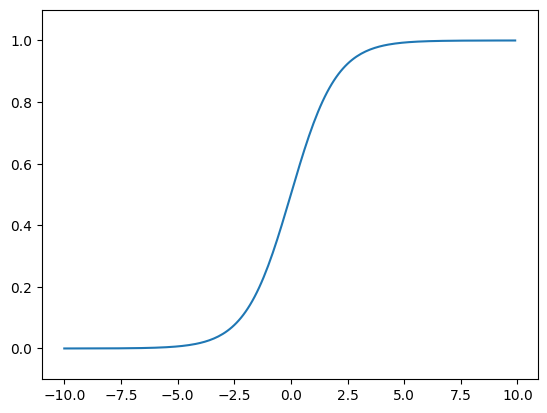

In [7]:
# sigmoid图像
# 和阶跃函数最大的不同就是平滑性，而平滑性意味可以输出除了0，1以外不同的值（信号强度不同，不再是二元数值）
# 有了平滑性就可以求导和反向传播；当然，其取值范围也是(0,1)
x=np.arange(-10,10,0.1)
y = sigmoid(x)

plt.plot(x,y)
plt.ylim(-0.1,1.1)
plt.show()

[0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.
 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7
 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 2.4 2.5
 2.6 2.7 2.8 2.9 3.  3.1 3.2 3.3 3.4 3.5 3.6 3.7 3.8 3.9 4.  4.1 4.2 4.3
 4.4 4.5 4.6 4.7 4.8 4.9 5.  5.1 5.2 5.3 5.4 5.5 5.6 5.7 5.8 5.9 6.  6.1
 6.2 6.3 6.4 6.5 6.6 6.7 6.8 6.9 7.  7.1 7.2 7.3 7.4 7.5 7.6 7.7 7.8 7.9
 8.  8.1 8.2 8.3 8.4 8.5 8.6 8.7 8.8 8.9 9.  9.1 9.2 9.3 9.4 9.5 9.6 9.7
 9.8 9.9]


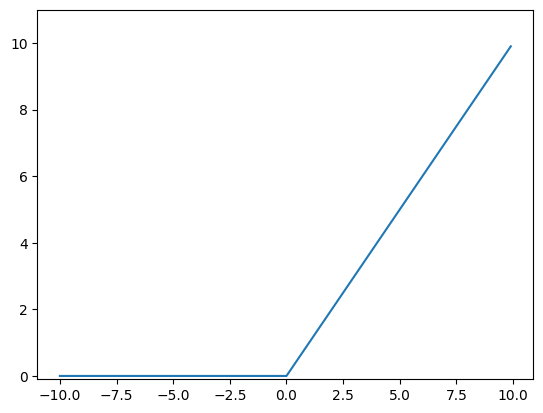

In [8]:
# 另外一种最基本的激活函数ReLU，现代改进后的激活函数很多也是来自于ReLU的变种，甚至就还在用ReLU
# ReLU是输入小于等于0输出0，否则直接输出数值
def relu(x):
    # maximum是对两个array或者标量逐元素比较并取对应位置的最大值，和max()函数做区分
    return np.maximum(x,0)

x = np.arange(-10,10,0.1)
y = relu(x)
print(y)

plt.plot(x,y)
plt.ylim(-0.1,11)
plt.show()

In [23]:

# 这里和鱼书写的不一样，主要是搞一下pytorch的方式并且封装成类，鱼书没有封装
class LinearWeight():
    def __init__(self,row,column) -> None:
        self.weight = np.random.random((row,column))
        # bias是偏置
        self.bias = np.random.random((row, 1))  # 列向量 (row,1)

class ModelNetwork:
    # 模型权重是用字典存的，这一点和pytorch一样，见pytorch的state_sict
    def __init__(self) -> None:
        self.network = {}
    
    # 初始化网络权重矩阵
    def weight_matrix(self,row:int,column:int,name:str) -> None:
        # 权重初始化，对应pytorch的全连接层权重矩阵
        init_array = LinearWeight(row,column)
        self.network[name] = init_array
    
    def calculate_weight_matrix(self, x: np.array, name: str) -> np.array:
        x = np.dot(self.network[name].weight, x) 
        print(x.shape)
        y = x+self.network[name].bias
        print(y.shape)
        
        return x
        
def forward(x):
    model = ModelNetwork()
    # 第一层参数WX转置+b，这里也和鱼书不一样，鱼书是XW，X也要按行排列。
    # 纯个人习惯，论文也都不一样，维度对齐就行
    # shape [3,2] [2,1] -> [3,1]
    model.weight_matrix(3,2,"l1")
    # shape [2,3] [3,1] -> [2,1]
    model.weight_matrix(2,3,"l2")
    # shape [2,2] [2,1] -> [2,1]
    model.weight_matrix(2,2,"l3")

    x = model.calculate_weight_matrix(x,"l1")
    # print(x.shape)
    x = model.calculate_weight_matrix(sigmoid(x),"l2")
    x = model.calculate_weight_matrix(sigmoid(x),"l3")

    return x
# reshape 为列向量，保证矩阵乘法语义 [n,1]
x = np.array([0.5, 0.5]).reshape(-1, 1)
print(forward(x))



(3, 1)
(3, 1)
(2, 1)
(2, 1)
(2, 1)
(2, 1)
[[0.20342936]
 [0.12204567]]


In [43]:
# softmax函数实现，按鱼书的内容，softmax也是激活函数的一种，只是用于输出层输出概率值
# 或者换句话讲，经过softmax后的输出作为下一层的输入，该输入已经有概率大小，每个神经元的重要性按照概率大小体现了出来（类似于归一化）
# 但是由于softmax中是指数函数，容易出现指数上溢，所以要做修改；一般做法是减去所计算输入的最大值，推导见鱼书
# 数据布局约定：类别维在倒数第二位，即 (..., n_class, 1)
# 对应 forward 输出的列向量形式 (n_class, 1)
# 若用 PyTorch 常见布局 (..., n_class)，则改为 axis=-1
def softmax(x):
    max_num = np.max(x, axis=-2, keepdims=True)   # 减去最大值防止上溢
    exp_x = np.exp(x - max_num)
    return exp_x / np.sum(exp_x, axis=-2, keepdims=True)

# 接上 forward 的输出直接验证
x = np.array([0.5, 0.5]).reshape(-1, 1)
out = forward(x)
prob = softmax(out)
print("输出 shape:", prob.shape)        # (2,1)
print("概率值:\n", prob)
print("概率和:", prob.sum(axis=-2))     # 应为 [[1.]]


(3, 1)
(3, 1)
(2, 1)
(2, 1)
(2, 1)
(2, 1)
输出 shape: (2, 1)
概率值:
 [[0.60064306]
 [0.39935694]]
概率和: [1.]


# 深度学习面试题（基于本文件涉及的知识点）

---

## 一、基础

### 1. 什么是激活函数？为什么需要激活函数？

**答：** 激活函数是作用在神经元输出上的非线性映射函数。如果没有激活函数，多层神经网络的叠加本质上仍是线性变换（多个线性变换的组合依旧是线性变换），无法拟合复杂的非线性关系。激活函数引入了非线性，使网络具有表达任意函数的能力（万能近似定理）。

#### 1.1 常见的激活函数有哪些？分别写出数学表达式。

**答：**
- **阶跃函数：** h(x) = 0 (x ≤ 0), h(x) = 1 (x > 0)
- **Sigmoid：** σ(x) = 1 / (1 + e^(-x))，输出范围 (0, 1)
- **ReLU：** f(x) = max(0, x)，输出范围 [0, +∞)
- **Softmax：** softmax(x_i) = e^(x_i) / Σ_j e^(x_j)，输出范围 (0, 1) 且各类概率和为 1

#### 1.2 阶跃函数和 Sigmoid 的核心区别是什么？

**答：** 阶跃函数的输出是离散的 0/1，不可导（在 x=0 处不连续）；Sigmoid 的输出是连续平滑的，处处可导。平滑性意味着：①可以输出 0 和 1 之间的中间值，表示信号的强弱程度；②可以求导，使得反向传播成为可能。

#### 1.3 Sigmoid 有哪些缺点？

**答：**
1. **梯度消失：** 当输入绝对值很大时，Sigmoid 的导数趋近于 0，梯度几乎无法传播到浅层。
2. **输出不以 0 为中心：** 输出范围 (0,1)，导致下一层收到的输入全为正数，梯度更新时权重只能同向变化（全正或全负），收敛慢（zig-zag 现象）。
3. **指数运算计算量大。**

### 2. 什么是 ReLU？相比 Sigmoid 有什么优势？

**答：** ReLU(x) = max(0, x)。优势：①正区间梯度恒为 1，不存在梯度消失问题；②计算非常简单（只是阈值判断），速度快；③实践中收敛速度远快于 Sigmoid/Tanh。

#### 2.1 ReLU 有什么缺点？有哪些改进变种？

**答：**

缺点：**Dead ReLU 问题**——当输入小于 0 时梯度为 0，如果某个神经元的输入始终为负（比如学习率过大导致权重更新后偏移），该神经元将永久"死亡"，不再更新。

常见变种：
- **Leaky ReLU：** f(x) = x (x>0), f(x) = αx (x≤0)，α 通常取 0.01，负区间有小梯度，避免死亡。
- **PReLU（Parametric ReLU）：** α 是可学习参数。
- **ELU：** f(x) = x (x>0), f(x) = α(e^x - 1) (x≤0)，负区间平滑，均值更接近 0。
- **GELU：** f(x) = x · Φ(x)，Transformer 中广泛使用。
- **Swish/SiLU：** f(x) = x · σ(x)，Google 提出，效果好于 ReLU。

### 3. 什么是偏置（bias）？为什么需要偏置？

**答：** 偏置是加在线性变换 Wx 结果上的常数项，即 y = Wx + b。没有偏置时，神经元的决策边界必须过原点；加上偏置后，决策边界可以平移，使模型拟合能力更强。

---

## 二、中级

### 4. Softmax 函数的作用是什么？为什么输出层用 Softmax 而不用 Sigmoid？

**答：** Softmax 将任意实数向量映射为概率分布（所有元素为正且和为 1），适合多分类任务。Sigmoid 对每个输出独立映射到 (0,1)，各输出之和不一定为 1，适合多标签分类（每个类别独立判断）而非互斥的多分类。

#### 4.1 Softmax 在实现时为什么要减去最大值？

**答：** Softmax 涉及指数运算 e^(x_i)，当 x_i 很大时（如 1000），e^1000 会溢出（上溢）。减去最大值 max(x) 后，最大的指数变为 e^0 = 1，其余为 e^(负数) ∈ (0,1)，数值稳定。数学上可以证明 softmax(x) = softmax(x - c) 对任意常数 c 成立，所以减去最大值不改变结果。

#### 4.2 Softmax 的 axis 参数应该怎么选？

**答：** axis 应指向**类别维度**。具体取决于数据布局：
- 列向量布局 (..., n_class, 1)：axis=-2
- 行向量布局 (..., n_class)：axis=-1（PyTorch 默认）

关键是 `keepdims=True`，保持维度不塌缩，确保除法时广播正确。

### 5. 前向传播的计算流程是什么？

**答：** 对于全连接网络，每一层的计算为：
1. 线性变换：z = Wx + b
2. 激活函数：a = h(z)
3. 将 a 作为下一层的输入，重复上述过程
4. 最后一层（输出层）根据任务选择激活函数：回归用恒等函数，二分类用 Sigmoid，多分类用 Softmax

#### 5.1 矩阵乘法 Wx 和 xW 有什么区别？

**答：** 本质上是数据布局的约定问题：
- **Wx 形式：** x 是列向量 (n_in, 1)，W 是 (n_out, n_in)，结果 (n_out, 1)。这是数学和论文中的常见写法。
- **xW 形式：** x 是行向量 (1, n_in)，W 是 (n_in, n_out)，结果 (1, n_out)。这是鱼书和部分框架的写法。

两者等价，只要维度对齐、保持一致即可。

#### 5.2 为什么权重不能全初始化为 0？

**答：** 如果所有权重都为 0（或相同值），那么同一层的所有神经元在前向传播中输出相同，反向传播中梯度也相同，更新后权重仍然相同——所有神经元完全对称，永远无法打破，等价于只有一个神经元。这称为**对称性问题**。所以权重需要随机初始化来打破对称。

### 6. NumPy 的广播（Broadcasting）机制是什么？

**答：** 当两个形状不同的数组做逐元素运算时，NumPy 按以下规则自动扩展：
1. 维度数不同，在较小数组的 shape 前面补 1
2. 从末尾开始逐维比较：相同则通过，其中一个为 1 则扩展，否则报错

例如 (3,) + (3,1)：(3,) → (1,3)，与 (3,1) 广播得 (3,3)。这就是为什么偏置的维度必须和线性变换输出匹配。

---

## 三、高级

### 7. 什么是梯度消失和梯度爆炸？如何解决？

**答：** 反向传播时梯度通过链式法则逐层相乘。如果每层的梯度 < 1（如 Sigmoid 的最大导数 0.25），多层相乘后梯度趋近于 0（梯度消失）；如果 > 1，多层相乘后趋于无穷（梯度爆炸）。

**解决方案：**
- 梯度消失：使用 ReLU/LeakyReLU；使用残差连接（ResNet）；使用 BatchNorm；合理的权重初始化（Xavier/He）
- 梯度爆炸：梯度裁剪（Gradient Clipping）；合理的权重初始化；BatchNorm

#### 7.1 为什么 Sigmoid 容易梯度消失，而 ReLU 不会？

**答：** Sigmoid 的导数 σ'(x) = σ(x)(1-σ(x))，最大值在 x=0 处为 0.25，恒 < 1。多层相乘：0.25^n → 0。ReLU 在正区间的导数恒为 1，梯度不缩小也不放大，有效缓解消失问题。

#### 7.2 Xavier 初始化和 He 初始化的区别？

**答：**
- **Xavier（Glorot）初始化：** W ~ N(0, 2/(n_in + n_out))，适配 Sigmoid/Tanh 等对称激活函数，保证前向和反向的方差一致。
- **He 初始化：** W ~ N(0, 2/n_in)，专为 ReLU 设计，因为 ReLU 会将一半神经元置零，方差需要加倍补偿。

### 8. 万能近似定理（Universal Approximation Theorem）是什么？

**答：** 一个具有单隐藏层的前馈神经网络，只要隐藏层有足够多的神经元，且使用任意非常数、有界、连续的激活函数，就可以以任意精度逼近任何定义在紧集上的连续函数。

#### 8.1 既然单隐藏层就够了，为什么还要深层网络？

**答：** 理论上可以，但所需神经元数量可能是指数级的。深层网络通过逐层抽象，用更少的参数达到相同甚至更好的拟合效果。例如，识别人脸时：第一层学边缘，第二层学局部结构（眼睛、鼻子），第三层学整体组合——层次化表示比扁平的单层高效得多。

---

## 四、困难

### 9. 神经网络的前向传播可以看作什么数学操作？为什么说"深度"很重要？

**答：** 前向传播是一系列仿射变换 + 非线性激活的复合函数：f(x) = h_n(W_n · h_{n-1}(... h_1(W_1 · x + b_1) ...) + b_n)。从函数空间角度看，每多一层就增加一次"折叠"能力——将输入空间做一次非线性变换。层数越深，空间被折叠得越复杂，决策边界可以越复杂。这就是为什么感知机（单层）只能解决线性可分问题，而多层网络可以解决 XOR 等线性不可分问题。

#### 9.1 XOR 为什么单层感知机无法解决？多层如何解决？

**答：** XOR 的真值表中，(0,0)→0, (0,1)→1, (1,0)→1, (1,1)→0。在二维平面上，输出 0 的点和输出 1 的点交叉分布在对角线上，无法用一条直线分割——即线性不可分。

多层感知机的解法：XOR(x1,x2) = AND(NAND(x1,x2), OR(x1,x2))。第一层并行计算 NAND 和 OR（两个线性可分的子问题），第二层用 AND 组合，等价于用两条直线将平面分成三个区域，实现非线性分割。

#### 9.2 从特征空间变换角度解释多层感知机如何解决 XOR？

**答：** 第一隐藏层将原始 2D 输入映射到新的 2D 特征空间。在这个新空间中，原本线性不可分的四个点变得线性可分了。例如：隐藏层两个神经元分别计算 s1=NAND(x1,x2) 和 s2=OR(x1,x2)，原始 (0,0)/(0,1)/(1,0)/(1,1) 映射到 (1,0)/(1,1)/(1,1)/(0,1)，在 s1-s2 空间中，(1,1) 可以被一条直线和其他点分开。

### 10. Softmax + Cross-Entropy Loss 的梯度是什么？为什么这个组合如此常用？

**答：** 设 softmax 输出为 p_i = e^(z_i) / Σe^(z_j)，交叉熵损失 L = -Σ y_i · log(p_i)（y 为 one-hot 标签），则梯度 ∂L/∂z_i = p_i - y_i。

这个结果极其简洁优美：梯度 = 预测值 - 真实标签。好处：
1. 计算简单，无需分别求 softmax 和 cross-entropy 的导数再链式相乘
2. 不会出现梯度消失（当预测错误时 p_i - y_i 的绝对值大，梯度大，更新快）
3. 数值稳定

#### 10.1 为什么不用均方误差（MSE）搭配 Softmax 做分类？

**答：** MSE + Softmax 的梯度为 (p_i - y_i) · p_i · (1 - p_i)，多了一个 p_i(1-p_i) 因子。当预测值 p_i 接近 0 或 1 时，这个因子趋近于 0，导致梯度消失，即使预测完全错误（如真实为 1，预测为 0.01），梯度也很小，学习极慢。而交叉熵的梯度 p_i - y_i 不受此影响。

### 11. 反向传播的本质是什么？为什么激活函数必须可导？

**答：** 反向传播是链式法则的高效实现。对于损失函数 L，要计算 ∂L/∂W 来更新权重，需要从输出层逐层向输入层传播梯度。每一层的梯度 = 上游梯度 × 本层函数的导数。如果激活函数不可导（如阶跃函数），链式法则断裂，梯度无法传播，网络无法学习。这就是阶跃函数在实际训练中不可用、必须换成 Sigmoid/ReLU 等可导函数的根本原因。

#### 11.1 ReLU 在 x=0 处不可导，为什么还能用？

**答：** 严格来说 ReLU 在 x=0 处不可导，但：①实际训练中输入恰好等于 0 的概率极低（浮点数精度）；②工程实现中直接令 x=0 处导数为 0（或 1），不影响训练效果；③从次梯度（subgradient）理论角度，这种处理是合理的。